# MNIST Digit Classification with a Fully-Connected Neural Network
*By Carlos Santiago Bañón*

**Year:** 2020

**Technologies:** Python, NumPy, Matplotlib, TensforFlow, Keras

**Discipline(s):** Computer Vision, Deep Learning

**Keywords:** `classification`, `computer-vision`, `deep-learning`, `fully-connected`, `mnist`, `multi-class-classification`, `neural-network`

This notebook presents an MNIST digit classifier built with a fully-connected neural network in TensorFlow and Keras.

## 1. Import Statements

---



In [175]:
import numpy as np
import matplotlib.pyplot as plt

%tensorflow_version 2.x
import tensorflow as tf

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


## 2. Data Preprocessing

---



The first step is to preprocess our data. Here, we load the MNIST digit dataset from the Keras datasets library, split it into training and test sets, reshape the matrices, and encode the labels categorically.

In [176]:
# Load the MNIST dataset.
mnist = tf.keras.datasets.mnist
train_data, test_data = mnist.load_data()

In [177]:
# Divide the data into features and labels.
train_images, train_labels = train_data
test_images, test_labels = test_data

In [178]:
# Reshape and normalize the images.
X_train = train_images.reshape((60000, 784))
X_train = X_train.astype('float32') / 255
X_test = test_images.reshape((10000, 784))
X_test = X_test.astype('float32') / 255

In [179]:
# Reshape the labels and encode them categorically.
y_train = tf.keras.utils.to_categorical(train_labels)
y_test = tf.keras.utils.to_categorical(test_labels)

Further, the following are the shapes of each matrix, as well as a visualization of a random MNIST digit.

In [180]:
# Show the shapes of the data.
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Test Labels:", y_test.shape)

Training Images: (60000, 784)
Testing Images: (10000, 784)
Training Labels: (60000, 10)
Test Labels: (10000, 10)


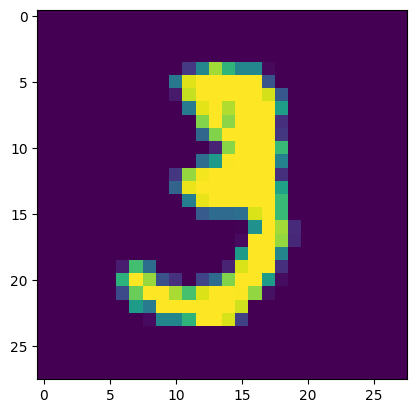

In [181]:
# Show a sample MNIST digit.
plt.imshow(train_images[10])
plt.show()

## 3. Neural Network

---



### 3.1. Define the Model

We then have to define our neural network. Here, we define a sequential model with two fully-connected layers.

In [182]:
# Define the sequential model.
model = tf.keras.models.Sequential()

In [203]:
# Add two fully-connected layers to the network.
model.add(tf.keras.layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [184]:
# Show the model.
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Once our model is defined, we can compile it using the Adam optimizer and the categorical cross-entropy loss function.

In [185]:
# Compile the model.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### 3.2. Train the Model

We then train the model on 10 epochs, using a batch size of 256.

In [186]:
# Define the parameters.
num_epochs = 20
batch_size = 256

# Train the model.
history = model.fit(X_train,
                      y_train,
                      epochs=num_epochs,
                      batch_size=batch_size,
                      validation_data=(X_test, y_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8565 - loss: 0.5187 - val_accuracy: 0.9218 - val_loss: 0.2795
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9306 - loss: 0.2479 - val_accuracy: 0.9369 - val_loss: 0.2157
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9447 - loss: 0.1967 - val_accuracy: 0.9487 - val_loss: 0.1775
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9532 - loss: 0.1657 - val_accuracy: 0.9528 - val_loss: 0.1605
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9596 - loss: 0.1430 - val_accuracy: 0.9579 - val_loss: 0.1386
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9646 - loss: 0.1251 - val_accuracy: 0.9618 - val_loss: 0.1237
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9679 - loss: 0.1119 - val_accuracy: 0.9655 - val_loss: 0.1154
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9714 - loss: 0.1000 - val_accuracy: 0.

### 3.3. Display the Metrics

Finally, we display the metrics. We begin by displaying the model's accuracy and loss based on the test set.

In [187]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print('Test Accuracy:', test_accuracy)
print('Test Loss:', test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9751 - loss: 0.0864
Test Accuracy: 0.9750999808311462
Test Loss: 0.08637798577547073


Then, we save the metric values for each epoch to plot the loss and accuracy curves for our model.

In [188]:
# Save the metrics.
metrics = history.history

Finally, once we have our metric history, we can plot the curves.

In [189]:
# Save the loss values.
training_loss_list = metrics['loss']
test_loss_list = metrics['val_loss']

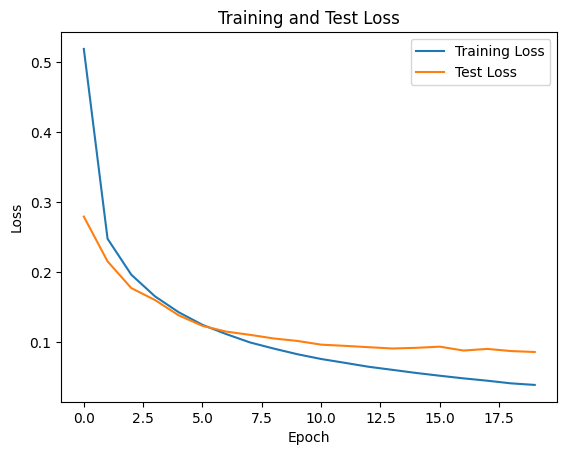

In [190]:
# Plot the training and test loss.
x = np.arange(0, num_epochs, 1)
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(x, training_loss_list, label='Training Loss')
plt.plot(x, test_loss_list, label='Test Loss')
plt.legend()
plt.show()

In [191]:
train_accuracy_list = metrics['accuracy']
test_accuracy_list = metrics['val_accuracy']

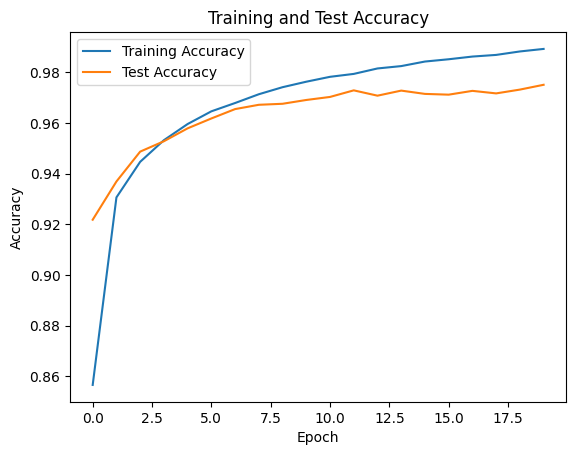

In [192]:
plt.title('Training and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(x, train_accuracy_list, label='Training Accuracy')
plt.plot(x, test_accuracy_list, label='Test Accuracy')
plt.legend()
plt.show()

## 4. Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [193]:
# Make predictions with the trained model.
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Finally, we can show a random test image with its corresponding prediction.

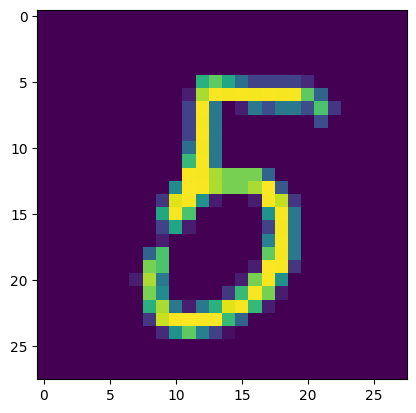

In [194]:
# Choose an index.
index = 45

# Show an image from the test set.
plt.imshow(test_images[index])
plt.show()

In [195]:
print("Prediction:", np.argmax(predictions[index]))

Prediction: 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


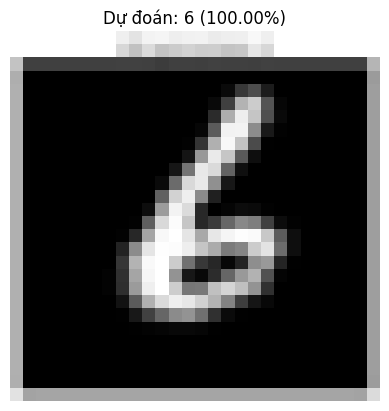

Xác suất chi tiết cho từng số (từ 0 đến 9):
Số 0: 0.00%
Số 1: 0.00%
Số 2: 0.00%
Số 3: 0.00%
Số 4: 0.00%
Số 5: 0.00%
Số 6: 100.00%
Số 7: 0.00%
Số 8: 0.00%
Số 9: 0.00%


In [205]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Đường dẫn tới file ảnh bạn vừa upload
image_path = 'z7952185335859_c9c36b140ce0243c9cba74eb0cd8602d.jpg'

# 2. Đọc ảnh, chuyển về ảnh xám (Grayscale - 'L') và resize bắt buộc về kích thước 28x28
img = Image.open(image_path).convert('L')
img = img.resize((28, 28))

# 3. Chuyển ảnh thành mảng Numpy
img_array = np.array(img)

# LƯU Ý QUAN TRỌNG:
# Mẫu ảnh của bộ dữ liệu MNIST gốc có NỀN ĐEN (giá trị 0) và CHỮ TRẮNG (giá trị gần 255).
# Nếu ảnh bạn chụp hoặc vẽ là NỀN TRẮNG CHỮ ĐEN, mô hình sẽ nhận diện sai hoàn toàn.
# Đoạn code dưới đây sẽ tự động đảo ngược màu nếu phát hiện nền là màu sáng (trắng).
#if img_array[0, 0] > 128:
 #   img_array = 255 - img_array

# 4. Chuẩn hóa dữ liệu về khoảng [0, 1] giống y hệt lúc train
img_norm = img_array.astype('float32') / 255.0

# 5. Reshape ảnh theo đúng cấu trúc đầu vào của mô hình bạn đã chọn
# BẬT ĐOẠN CODE NÀY NẾU BẠN DÙNG MẠNG DENSE (FULLY-CONNECTED)
img_input = img_norm.reshape(1, 784)

# BẬT ĐOẠN CODE NÀY NẾU BẠN DÙNG MẠNG CNN (28x28x1)
# img_input = img_norm.reshape(1, 28, 28, 1)

# 6. Tiến hành dự đoán (Predict)
predictions = model.predict(img_input)
predicted_label = np.argmax(predictions) # Lấy vị trí có xác suất cao nhất
confidence = np.max(predictions) * 100   # Độ tự tin (%)

# 7. Hiển thị kết quả trực quan
plt.imshow(img_array, cmap='gray')
plt.title(f"Dự đoán: {predicted_label} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Xác suất chi tiết cho từng số (từ 0 đến 9):")
for i, prob in enumerate(predictions[0]):
    print(f"Số {i}: {prob*100:.2f}%")

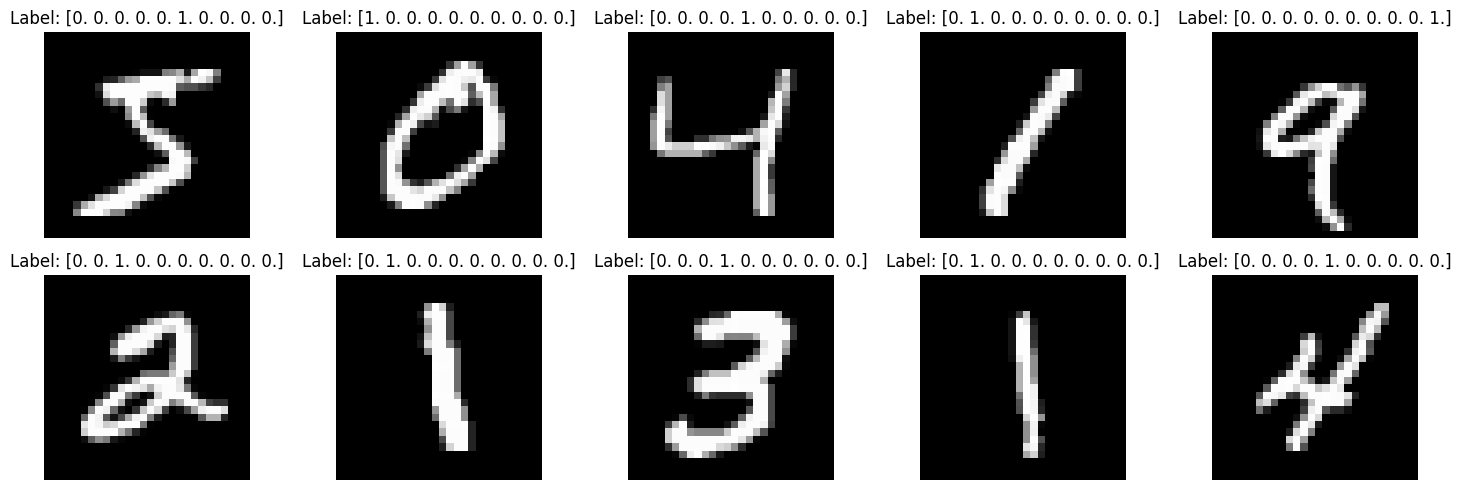

In [207]:
import matplotlib.pyplot as plt

# Thiết lập hiển thị 10 ảnh
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Hiển thị ảnh ở dạng thang độ xám (grayscale)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')

    # Lấy nhãn tương ứng (lưu ý: nếu bạn đã dùng to_categorical thì y_train là dạng one-hot,
    # nếu bạn dùng biến gốc trước đó thì y_train là số)
    # Ở đây giả sử y_train là nhãn gốc (0-9)
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off') # Tắt hiển thị trục tọa độ

plt.tight_layout()
plt.show()